
# Clustering Algorithms using sklearn (KMeans and MinimBatch KMeans)

**Learning Outcomes**
1. Implement a clustering solution using K-Means model from sklearn
2. Implement a clustering solution using mini-batch K-Means model from sklearn
3. Compare between the performances of both algorithms to appreciate their subtle differences


We want to compare the performance of the MiniBatch KMeans and KMeans: the MiniBatchKMeans is faster, but gives slightly different results.

We will cluster a dataset, first with KMeans and then with MiniBatchKMeans, and plot the results.
We will also plot the points that are labelled differently between the two algorithms.

Disclaimer: this exercise is adopted from [sklearn](https://scikit-learn.org/stable/auto_examples/cluster/plot_mini_batch_kmeans.html).


In [1]:
%matplotlib inline
from IPython.display import display, HTML
display(HTML('<style>.container {width: 85% !important}</style>'))

%set_env OMP_NUM_THREADS=1  
#to avoid a memory leak on windows with MiniBatchKMeans

env: OMP_NUM_THREADS=1


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics.pairwise import pairwise_distances_argmin
from sklearn.datasets import make_blobs

## Generate sample data

In [3]:
np.random.seed(0)

batch_size = 45
centers = [[1, 1], [-1, -1], [1, -1]]
n_clusters = len(centers)
X, labels_true = make_blobs(n_samples=3000, centers=centers, cluster_std=0.7)


## Cluster the data using [K-means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans )

In [4]:
k_means = KMeans(init='random', n_clusters=3, n_init=10)
t0 = time.time()
k_means.fit(X)
t_batch = time.time() - t0

## Clustering the data using [MiniBatchKMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html#sklearn.cluster.MiniBatchKMeans )

In [5]:
mbk = MiniBatchKMeans(init='k-means++', n_clusters=3, batch_size=batch_size,
                      n_init=10, max_no_improvement=10, verbose=0)
t0 = time.time()
mbk.fit(X)
t_mini_batch = time.time() - t0

## Plot the results

In [6]:
### helper functions
def clust_plot(points, center):
    ax.plot(X[points, 0], X[points, 1], 'o', markersize=4,  markerfacecolor=col )
    ax.plot(   center[0],    center[1], '+', markersize=16, markerfacecolor=col, markeredgecolor='k')

def set_fig(title, time, inertia):
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())
    plt.text(-3.5, 1.8, 'train time: %.2fs\ninertia: %f' %(time, inertia))
    


Plot K-means and mini batch K-means and the differences between them in three subplots.


[ True False False ... False False False]
[False  True  True ...  True  True  True]


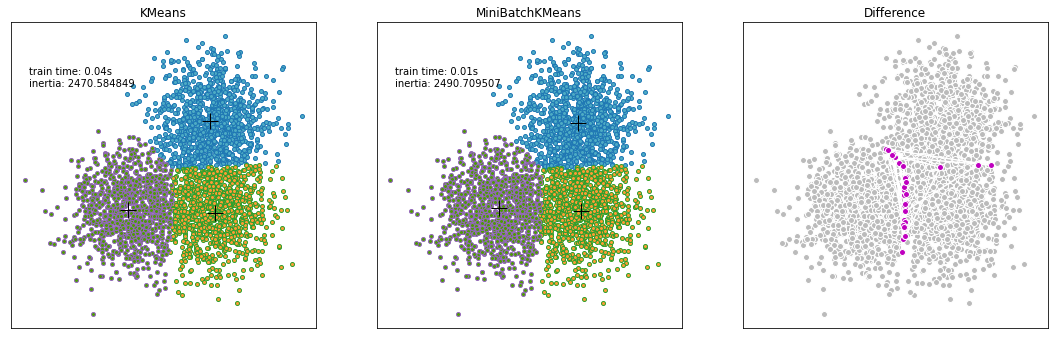

In [7]:
fig = plt.figure(figsize=(15, 5))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.05, top=0.9)
colors = ['#4EACC5', '#FF9C34', '#4E9A06']
# We want to have the same colours for the same cluster from the MiniBatchKMeans and the KMeans 
# algorithm. Let's pair the cluster centers per closest one.

k_centers = k_means.cluster_centers_
order = pairwise_distances_argmin(k_means.cluster_centers_, mbk.cluster_centers_)
#print (k_means.cluster_centers_, mbk.cluster_centers_)
#print (order)
mbk_centers = mbk.cluster_centers_[order]

k_labels   = pairwise_distances_argmin(X, k_centers)
mbk_labels = pairwise_distances_argmin(X, mbk_centers)

    
# KMeans-------------------------------------------------------------------------------------------------------
ax = fig.add_subplot(1, 3, 1)
for k, col in zip(range(n_clusters), colors):
    clust_points = k_labels == k
    clust_center = k_centers[k]
    clust_plot(clust_points, clust_center)

set_fig('KMeans', t_batch, k_means.inertia_)  #inertia or within-clusters sum-of-squares criterion

# MiniBatchKMeans-----------------------------------------------------------------------------------------------
ax = fig.add_subplot(1, 3, 2)
for k, col in zip(range(n_clusters), colors):
    clust_points = mbk_labels == k
    clust_center = mbk_centers[k]
    clust_plot(clust_points, clust_center)

set_fig('MiniBatchKMeans', t_mini_batch, mbk.inertia_)
    
# Initialise the different array to all False-------------------------------------------------------------------
different = (mbk_labels == 4)
ax = fig.add_subplot(1, 3, 3)

for k in range(n_clusters):
    different += ((k_labels == k) != (mbk_labels == k))

identic = np.logical_not(different)

print(different)
print(identic)

ax.plot(X[identic,   0], X[identic,   1], 'w', markerfacecolor='#bbbbbb', marker='.', markersize=12)
ax.plot(X[different, 0], X[different, 1], 'w', markerfacecolor='m',       marker='.', markersize=12)
ax.set_title('Difference')
ax.set_xticks(())
ax.set_yticks(())

plt.show()
